In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def softcap(x: torch.Tensor, cap: float) -> torch.Tensor:
    return cap * torch.tanh(x / cap)

In [17]:
class MLP(nn.Module):
    def __init__(self, cap: float | None = None, hard: bool = False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )
        self.cap = cap
        self.hard = hard

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.net(x)
        if self.cap is not None:
            if self.hard:
                logits = logits.clamp(-self.cap, self.cap)
            else:
                logits = softcap(logits, self.cap)
        return logits

In [9]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST(root="/tmp/mnist", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="/tmp/mnist", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.43MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 224kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.01MB/s]


In [ ]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, epochs=5):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, test_accs = [], []
    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        epoch_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(model(x), y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item() # IMPORTANT: produces invalid ranking for same logits (e.g. from hardcap training)
        test_accs.append(correct / len(test_ds))
    return train_losses, test_accs

torch.manual_seed(0)
model_base = MLP(cap=None)
losses_base, accs_base = train(model_base)

In [ ]:
torch.manual_seed(0)
model_cap20 = MLP(cap=20.0)
losses_cap20, accs_cap20 = train(model_cap20)

In [ ]:
torch.manual_seed(0)
model_cap5 = MLP(cap=5.0)
losses_cap5, accs_cap5 = train(model_cap5)

In [18]:
torch.manual_seed(0)
model_hardcap5 = MLP(cap=5.0, hard=True)
losses_hardcap5, accs_hardcap5 = train(model_hardcap5)

Training: 100%|██████████| 5/5 [00:19<00:00,  3.89s/it]


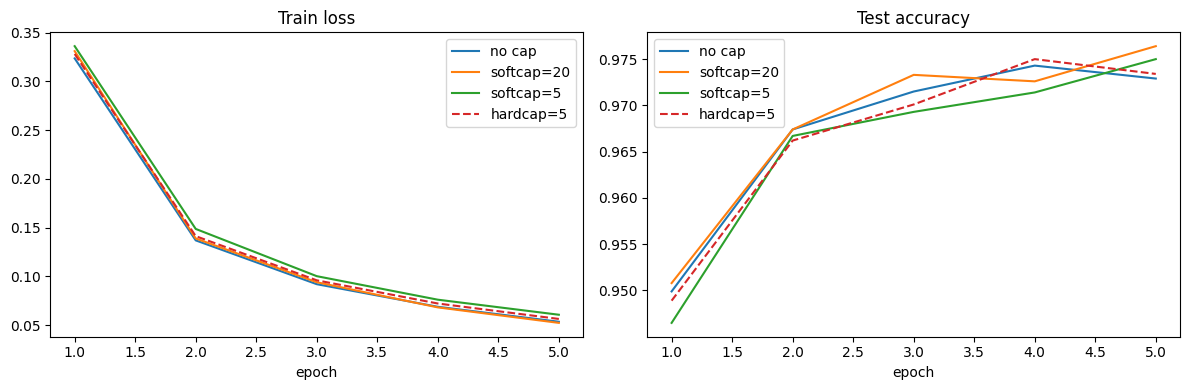

In [19]:
epochs = range(1, len(accs_base) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, losses_base,     label="no cap")
axes[0].plot(epochs, losses_cap20,    label="softcap=20")
axes[0].plot(epochs, losses_cap5,     label="softcap=5")
axes[0].plot(epochs, losses_hardcap5, label="hardcap=5", linestyle="--")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, accs_base,     label="no cap")
axes[1].plot(epochs, accs_cap20,    label="softcap=20")
axes[1].plot(epochs, accs_cap5,     label="softcap=5")
axes[1].plot(epochs, accs_hardcap5, label="hardcap=5", linestyle="--")
axes[1].set_title("Test accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

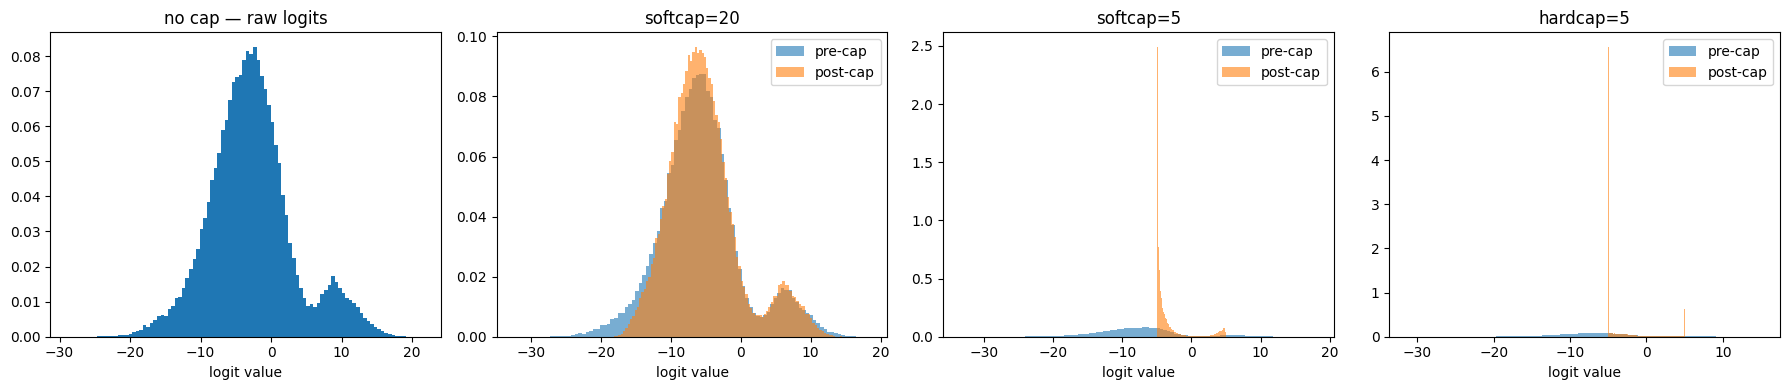

In [20]:
def collect_logits(model):
    model.eval()
    raw, capped = [], []
    def hook(module, input, output):
        raw.append(output.detach().cpu())
    h = model.net[-1].register_forward_hook(hook)
    with torch.no_grad():
        for x, _ in test_loader:
            out = model(x.to(device))
            capped.append(out.cpu())
    h.remove()
    return torch.cat(raw).numpy().ravel(), torch.cat(capped).numpy().ravel()

raw_base,      _             = collect_logits(model_base)
raw_cap20,     cap20_out     = collect_logits(model_cap20)
raw_cap5,      cap5_out      = collect_logits(model_cap5)
raw_hardcap5,  hardcap5_out  = collect_logits(model_hardcap5)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

axes[0].hist(raw_base, bins=100, density=True)
axes[0].set_title("no cap — raw logits")

axes[1].hist(raw_cap20, bins=100, density=True, alpha=0.6, label="pre-cap")
axes[1].hist(cap20_out, bins=100, density=True, alpha=0.6, label="post-cap")
axes[1].set_title("softcap=20")
axes[1].legend()

axes[2].hist(raw_cap5, bins=100, density=True, alpha=0.6, label="pre-cap")
axes[2].hist(cap5_out, bins=100, density=True, alpha=0.6, label="post-cap")
axes[2].set_title("softcap=5")
axes[2].legend()

axes[3].hist(raw_hardcap5, bins=100, density=True, alpha=0.6, label="pre-cap")
axes[3].hist(hardcap5_out, bins=100, density=True, alpha=0.6, label="post-cap")
axes[3].set_title("hardcap=5")
axes[3].legend()

for ax in axes:
    ax.set_xlabel("logit value")
plt.tight_layout()
plt.show()

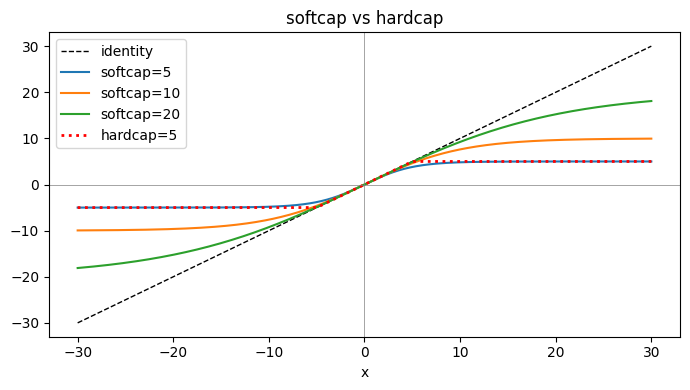

In [21]:
x = np.linspace(-30, 30, 500)
plt.figure(figsize=(7, 4))
plt.plot(x, x, "k--", label="identity", linewidth=1)
for cap in [5, 10, 20]:
    plt.plot(x, cap * np.tanh(x / cap), label=f"softcap={cap}")
plt.plot(x, np.clip(x, -5, 5), label="hardcap=5", linestyle=":", color="red", linewidth=2)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("softcap vs hardcap")
plt.xlabel("x")
plt.legend()
plt.tight_layout()
plt.show()